# 地形增强算法验证

本 Jupyter Notebook 使用官方测试数据验证迁移后的地形增强算法实现。

2x2 对比图包含以下内容：
- 原始输入数据图：官方样例中的输入地形场。
- 修改后算法数据图：由 `src/orographic_enhancement.py` 计算得到。
- 官方预期数据图：资源目录中提供的 KGO 结果。
- 原算法结果图：旧版算法预先保存的输出结果。
- 原算法CLI结果图：旧版算法CLI指令输出结果。


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import Normalize


PACKAGE_ROOT = Path.cwd().resolve().parents[0] #包根目录
PROJECT_ROOT = PACKAGE_ROOT.parent # 项目根目录
DATA_DIR = PACKAGE_ROOT / "test_data" / "orographic_enhancement_data" #测试数据路径
NORMALIZED_DIR = DATA_DIR / "normalized_meb6d" #预处理后数据路径

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from orographic_enhancement.src.orographic_enhancement import MetaOrographicEnhancement


plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"包根目录: {PACKAGE_ROOT}")
print(f"数据目录: {DATA_DIR}")


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


包根目录: D:\workspace\improver\orographic_enhancement
数据目录: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data


## 数据预处理

In [2]:
"""将一般 xarray 网格数据预处理为 meteva_base 标准六维网格。

处理策略（显式、稳定）：
1. 选择目标变量；
2. 若存在投影坐标与 CRS，则先转成经纬度坐标；
3. 显式识别各维度名（member/level/time/dtime/lat/lon）；
4. 先把空间坐标方向统一为升序（lat、lon）；
5. 调用 meteva_base.xarray_to_griddata 转为标准六维；
6. 补齐必要属性并保存。
"""

from __future__ import annotations

import argparse
import warnings
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import xarray as xr

import meteva_base as meb

try:
    from pyproj import CRS, Transformer
except Exception:  # pragma: no cover
    CRS = None
    Transformer = None

REQUIRED_DIMS = ("member", "level", "time", "dtime", "lat", "lon")
DEFAULT_ATTRS = {
    "units": "",
    "model": "",
    "dtime_units": "hour",
    "level_type": "isobaric",
    "time_type": "UT",
    "time_bounds": [0, 0],
}


def _pick_data_var(dataset: xr.Dataset, var_name: Optional[str]) -> xr.DataArray:
    """选择要处理的数据变量。"""
    if var_name:
        if var_name not in dataset.data_vars:
            raise ValueError(f"变量 {var_name} 不存在，可选: {list(dataset.data_vars)}")
        return dataset[var_name]

    if not dataset.data_vars:
        raise ValueError("输入文件没有可处理的数据变量")

    selected_name, selected_var = max(
        dataset.data_vars.items(), key=lambda item: (item[1].ndim, item[1].size)
    )
    print(f"[INFO] 未指定变量，自动选择: {selected_name}")
    return selected_var


def _fill_required_attrs(attrs: dict) -> dict:
    """补齐 meteva_base 常用属性（仅缺失时补）。"""
    merged = dict(attrs)
    for key, default in DEFAULT_ATTRS.items():
        if key not in merged or merged[key] in (None, ""):
            merged[key] = default
    return merged


def _find_grid_mapping_name(dataset: xr.Dataset, data: xr.DataArray) -> Optional[str]:
    """查找数据变量对应的 grid_mapping 变量名。"""
    gm = data.attrs.get("grid_mapping")
    if isinstance(gm, str) and gm in dataset.variables:
        return gm
    return None


def _build_transformer(dataset: xr.Dataset, data: xr.DataArray) -> Optional[Transformer]:
    """从 CF grid_mapping 构造投影到经纬度的转换器。"""
    if CRS is None or Transformer is None:
        return None
    grid_mapping_name = _find_grid_mapping_name(dataset, data)
    if grid_mapping_name is None:
        return None

    attrs = dict(dataset[grid_mapping_name].attrs)
    try:
        if "crs_wkt" in attrs and attrs["crs_wkt"]:
            source_crs = CRS.from_wkt(attrs["crs_wkt"])
        else:
            source_crs = CRS.from_cf(attrs)
        return Transformer.from_crs(source_crs, CRS.from_epsg(4326), always_xy=True)
    except Exception as exc:
        warnings.warn(f"无法解析 grid_mapping={grid_mapping_name}，跳过坐标转换: {exc}")
        return None


def _regularize_axis(values: np.ndarray) -> np.ndarray:
    """将一维坐标规整为等间距，降低浮点噪声影响。"""
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size < 2:
        return arr
    step = np.nanmedian(np.diff(arr))
    if not np.isfinite(step) or np.isclose(step, 0.0):
        return arr
    return arr[0] + step * np.arange(arr.size, dtype=np.float64)


def _convert_projection_to_latlon(
    data: xr.DataArray, dataset: xr.Dataset
) -> Tuple[xr.DataArray, bool]:
    """若存在投影坐标与 CRS，将 projection_x/y_coordinate 转换为 lon/lat。"""
    if "projection_y_coordinate" not in data.dims or "projection_x_coordinate" not in data.dims:
        return data, False

    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None or y_coord.ndim != 1 or x_coord.ndim != 1:
        return data, False

    transformer = _build_transformer(dataset, data)
    if transformer is None:
        return data, False

    x_vals = np.asarray(x_coord.values, dtype=np.float64)
    y_vals = np.asarray(y_coord.values, dtype=np.float64)
    xx, yy = np.meshgrid(x_vals, y_vals)
    lon2d, lat2d = transformer.transform(xx, yy)

    lat_1d = _regularize_axis(np.nanmean(lat2d, axis=1))
    lon_1d = _regularize_axis(np.nanmean(lon2d, axis=0))

    out = data.rename(
        {
            "projection_y_coordinate": "lat",
            "projection_x_coordinate": "lon",
        }
    ).assign_coords(
        lat=("lat", lat_1d.astype(np.float64)),
        lon=("lon", lon_1d.astype(np.float64)),
    )

    attrs = dict(out.attrs)
    attrs.pop("grid_mapping", None)
    out.attrs = attrs
    return out, True


def _first_existing(items: tuple[str, ...], names: tuple[str, ...]) -> Optional[str]:
    """返回候选列表中第一个存在于 names 的名字。"""
    for item in items:
        if item in names:
            return item
    return None


def _infer_dim_mapping(data: xr.DataArray) -> dict:
    """显式识别输入数据维度映射。"""
    dims = tuple(data.dims)
    lat_dim = _first_existing(("lat", "latitude", "projection_y_coordinate", "y"), dims)
    lon_dim = _first_existing(("lon", "longitude", "projection_x_coordinate", "x"), dims)

    if lat_dim is None or lon_dim is None:
        if len(dims) < 2:
            raise ValueError(f"无法识别空间维度，当前维度: {dims}")
        lat_dim, lon_dim = dims[-2], dims[-1]

    member_dim = _first_existing(("member", "realization", "number", "ensemble_member"), dims)
    level_dim = _first_existing(("level", "height", "pressure"), dims)
    time_dim = _first_existing(("time", "valid_time"), dims)
    dtime_dim = _first_existing(("dtime", "forecast_period", "leadtime"), dims)

    # 防止把空间维误判成其他维。
    if member_dim in {lat_dim, lon_dim}:
        member_dim = None
    if level_dim in {lat_dim, lon_dim}:
        level_dim = None
    if time_dim in {lat_dim, lon_dim}:
        time_dim = None
    if dtime_dim in {lat_dim, lon_dim}:
        dtime_dim = None

    return {
        "member_dim": member_dim,
        "level_dim": level_dim,
        "time_dim": time_dim,
        "dtime_dim": dtime_dim,
        "lat_dim": lat_dim,
        "lon_dim": lon_dim,
    }


def _normalize_dtime_coord(data: xr.DataArray, dtime_dim: Optional[str]) -> xr.DataArray:
    """将 dtime/forecast_period 协调为整型小时。"""
    if dtime_dim is None or dtime_dim not in data.coords:
        return data
    coord = data.coords[dtime_dim]
    values = np.asarray(coord.values)
    if np.issubdtype(values.dtype, np.timedelta64):
        hours = (values / np.timedelta64(1, "h")).astype(np.int32)
        data = data.assign_coords({dtime_dim: hours})
    return data


def _sort_spatial_coords(data: xr.DataArray, lat_dim: str, lon_dim: str) -> xr.DataArray:
    """确保空间坐标升序（南到北，西到东）。"""
    if lat_dim in data.coords:
        data = data.sortby(lat_dim)
    if lon_dim in data.coords:
        data = data.sortby(lon_dim)
    return data


def _to_meb6d(data: xr.DataArray) -> xr.DataArray:
    """将数据转为 meteva_base 标准六维网格。"""
    mapping = _infer_dim_mapping(data)
    data = _normalize_dtime_coord(data, mapping["dtime_dim"])
    data = _sort_spatial_coords(data, mapping["lat_dim"], mapping["lon_dim"])

    out = meb.xarray_to_griddata(
        data,
        value_name=data.name,
        member_dim=mapping["member_dim"],
        level_dim=mapping["level_dim"],
        time_dim=mapping["time_dim"],
        dtime_dim=mapping["dtime_dim"],
        lat_dim=mapping["lat_dim"],
        lon_dim=mapping["lon_dim"],
    )
    out = out.transpose(*REQUIRED_DIMS).astype(np.float32, copy=False)
    out = out.sortby("lat").sortby("lon")
    out.attrs = _fill_required_attrs(dict(out.attrs))
    return out


def preprocess_to_meb6d(input_path: str, output_path: str, var_name: Optional[str] = None) -> None:
    """执行预处理并写出结果。"""
    ds = xr.open_dataset(input_path, decode_timedelta=False)
    data = _pick_data_var(ds, var_name).copy()
    data.name = data.name or "data"

    merged_attrs = dict(data.attrs)
    if "model" not in merged_attrs and "mosg__model_configuration" in ds.attrs:
        merged_attrs["model"] = ds.attrs.get("mosg__model_configuration", "")
    data.attrs = _fill_required_attrs(merged_attrs)

    data, converted = _convert_projection_to_latlon(data, ds)
    if converted:
        print("[INFO] 已执行投影坐标 -> 经纬度转换。")
    else:
        print("[INFO] 未执行投影转换（无投影坐标或无可用 CRS）。")

    normalized = _to_meb6d(data)
    normalized.name = data.name

    # netCDF 不接受 None 属性值，统一转空字符串。
    safe_attrs = {}
    for key, value in normalized.attrs.items():
        safe_attrs[key] = "" if value is None else value
    normalized.attrs = safe_attrs

    out_path = Path(output_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    normalized.to_dataset(name=normalized.name).to_netcdf(out_path)

    print(f"[OK] 输出文件: {out_path}")
    print(f"[OK] 输出维度: {normalized.dims}")
    print(
        "[OK] lat方向: "
        f"{float(normalized.lat.values[0]):.6f} -> {float(normalized.lat.values[-1]):.6f}"
    )
    print(
        "[OK] lon方向: "
        f"{float(normalized.lon.values[0]):.6f} -> {float(normalized.lon.values[-1]):.6f}"
    )

# 预处理：将验证数据升维为 meteva_base 六维（含投影坐标转经纬度）
RUN_PREPROCESS = False

NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)

jobs = [
    ("temperature.nc", "air_temperature"),
    ("humidity.nc", "relative_humidity"),
    ("pressure.nc", "air_pressure"),
    ("wind_speed.nc", "wind_speed"),
    ("wind_direction.nc", "wind_from_direction"),
    ("orography_uk-standard_1km.nc", "surface_altitude"),
    ("kgo_hi_res.nc", "orographic_enhancement"),
    ("original_algorithm_result.nc", "orographic_enhancement"),
    ("original_cli_result.nc", "orographic_enhancement"),
]

if RUN_PREPROCESS:
    for filename, var_name in jobs:
        in_file = DATA_DIR / filename
        out_file = NORMALIZED_DIR / filename
        print(f"正在处理: {filename}")
        preprocess_to_meb6d(str(in_file), str(out_file), var_name=var_name)
    print("预处理完成，输出目录:", NORMALIZED_DIR)
else:
    print("跳过预处理（RUN_PREPROCESS=False），输出目录:", NORMALIZED_DIR)


跳过预处理（RUN_PREPROCESS=False），输出目录: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\normalized_meb6d


## MetaOrographicEnhancement

### 读取输入数据

In [3]:
def open_dataarray(filename: str, variable_name: str) -> xr.DataArray:
    """优先从 normalized_meb6d 读取变量并立即加载到内存。"""
    base_dir = NORMALIZED_DIR if NORMALIZED_DIR.exists() else DATA_DIR
    dataset = xr.open_dataset(base_dir / filename, decode_timedelta=False)
    try:
        return dataset[variable_name].load()
    finally:
        dataset.close()


print(f"数据读取目录: {NORMALIZED_DIR if NORMALIZED_DIR.exists() else DATA_DIR}")

temperature_da = open_dataarray("temperature.nc", "air_temperature")
humidity_da = open_dataarray("humidity.nc", "relative_humidity")
pressure_da = open_dataarray("pressure.nc", "air_pressure")
wind_speed_da = open_dataarray("wind_speed.nc", "wind_speed")
wind_direction_da = open_dataarray("wind_direction.nc", "wind_from_direction")
topography_da = open_dataarray("orography_uk-standard_1km.nc", "surface_altitude")
kgo_da = open_dataarray("kgo_hi_res.nc", "orographic_enhancement")
original_da = open_dataarray("original_algorithm_result.nc", "orographic_enhancement")
cli_da = open_dataarray("original_cli_result.nc", "orographic_enhancement")

数据读取目录: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\normalized_meb6d


### 插件类调用

In [4]:
#插件类应用
plugin = MetaOrographicEnhancement()
migrated_da = plugin(
    temperature_da,
    humidity_da,
    pressure_da,
    wind_speed_da,
    wind_direction_da,
    topography_da,
)
migrated_da.name = "orographic_enhancement"

In [5]:
from orographic_enhancement.utils.utils import check_for_meb_griddata
check_for_meb_griddata(migrated_da)

<xarray.DataArray 'orographic_enhancement' (member: 1, level: 1, time: 1,
                                            dtime: 1, lat: 199, lon: 202)> Size: 161kB
array([[[[[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
            5.7217766e-24, 0.0000000e+00, 0.0000000e+00],
           [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
            1.2401341e-11, 0.0000000e+00, 0.0000000e+00],
           [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
            5.2852318e-09, 0.0000000e+00, 0.0000000e+00],
           ...,
           [0.0000000e+00, 1.2444387e-07, 1.4997471e-07, ...,
            0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
           [0.0000000e+00, 7.0572653e-08, 1.0749132e-07, ...,
            0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
           [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
            0.0000000e+00, 0.0000000e+00, 0.0000000e+00]]]]]],
      shape=(1, 1, 1, 1, 199, 202), dtype=float32)
Coordinates:
  * member   (member) <U21 84B '0'
  * level    (level) float32 4B 0.0
  * time     (time) datetime64[us] 8B 2006-08-09T09:16:00
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float64 2kB 56.34 56.35 56.36 56.37 ... 58.1 58.11 58.12
  * lon      (lon) float64 2kB -6.793 -6.777 -6.76 -6.743 ... -3.5 -3.484 -3.467
Attributes:
    units:        m s-1
    model:        
    dtime_units:  hour
    level_type:   isobaric
    time_type:    UT
    time_bounds:  [0 0]
    long_name:    orographic_enhancement

In [6]:
def ensure_2d(data: xr.DataArray) -> xr.DataArray:
    """Squeeze length-1 dimensions and ensure the result is two-dimensional."""
    result = data.squeeze(drop=True)
    if result.ndim != 2:
        raise ValueError(f"Expected a 2D field, got dims={result.dims}")
    return result


def to_plot_2d(data: xr.DataArray) -> xr.DataArray:
    """Reduce a field to a representative 2D slice for plotting."""
    candidate_pairs = [
        ("projection_y_coordinate", "projection_x_coordinate"),
        ("lat", "lon"),
        ("latitude", "longitude"),
    ]
    dims_set = set(data.dims)
    selected_pair = None
    for y_name, x_name in candidate_pairs:
        if y_name in dims_set and x_name in dims_set:
            selected_pair = (y_name, x_name)
            break
    if selected_pair is None:
        if data.ndim < 2:
            raise ValueError(f"Cannot infer spatial dims from dims={data.dims}")
        selected_pair = (data.dims[-2], data.dims[-1])
    spatial_dims = set(selected_pair)
    indexers = {dim: 0 for dim in data.dims if dim not in spatial_dims}
    reduced = data.isel(indexers, drop=True) if indexers else data
    return ensure_2d(reduced)


def orient_for_plot(data_2d: xr.DataArray) -> xr.DataArray:
    """Ensure plot coordinates are ascending so all panels share orientation."""
    result = ensure_2d(data_2d).copy()
    y_name, x_name = result.dims
    y_vals = result.coords[y_name].values
    x_vals = result.coords[x_name].values
    if y_vals.size > 1 and y_vals[0] > y_vals[-1]:
        result = result.isel({y_name: slice(None, None, -1)})
    if x_vals.size > 1 and x_vals[0] > x_vals[-1]:
        result = result.isel({x_name: slice(None, None, -1)})
    return result


def plot_field(ax, data: xr.DataArray, title: str, cmap: str, norm=None):
    """Plot a 2D field with stable coordinate direction and axis limits."""
    plot_data = orient_for_plot(to_plot_2d(data))
    y_name, x_name = plot_data.dims
    x_vals = plot_data.coords[x_name].values
    y_vals = plot_data.coords[y_name].values
    mesh = ax.pcolormesh(
        x_vals,
        y_vals,
        plot_data.values,
        shading="auto",
        cmap=cmap,
        norm=norm,
    )
    ax.set_xlim(float(np.nanmin(x_vals)), float(np.nanmax(x_vals)))
    ax.set_ylim(float(np.nanmin(y_vals)), float(np.nanmax(y_vals)))
    ax.set_title(title)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_aspect("equal")
    return mesh


def _axis_min_max(arr: xr.DataArray, dim: str):
    vals = arr.coords[dim].values
    return float(np.nanmin(vals)), float(np.nanmax(vals))


def align_2d_with_axis_flip(candidate: xr.DataArray, reference: xr.DataArray):
    """严格对齐二维场；若仅坐标反序则自动翻转后再对齐。"""
    cand = ensure_2d(candidate).copy()
    ref = ensure_2d(reference).copy()
    if cand.dims != ref.dims:
        raise ValueError(f"维度名不一致: candidate={cand.dims}, reference={ref.dims}")

    coord_fix = {}
    for dim in cand.dims:
        c = cand.coords[dim].values
        r = ref.coords[dim].values
        if c.shape != r.shape:
            raise ValueError(f"坐标长度不一致: dim={dim}, candidate={c.shape[0]}, reference={r.shape[0]}")
        if np.allclose(c, r, equal_nan=True):
            coord_fix[dim] = ref.coords[dim].values
            continue
        if np.allclose(c[::-1], r, equal_nan=True):
            cand = cand.isel({dim: slice(None, None, -1)})
            coord_fix[dim] = ref.coords[dim].values
            continue
        c0, c1 = _axis_min_max(cand, dim)
        r0, r1 = _axis_min_max(ref, dim)
        raise ValueError(
            f"坐标标签不匹配: dim={dim}, candidate_range=[{c0}, {c1}], reference_range=[{r0}, {r1}]"
        )

    cand = cand.assign_coords(coord_fix)
    cand, ref = xr.align(cand, ref, join="exact")
    return cand, ref


def diff_stats(label: str, candidate: xr.DataArray, reference: xr.DataArray) -> dict:
    """Build summary statistics relative to a reference field."""
    candidate_2d, reference_2d = align_2d_with_axis_flip(candidate, reference)
    diff = candidate_2d.values - reference_2d.values
    abs_diff = np.abs(diff)
    return {
        "comparison": label,
        "max_abs_error": float(np.nanmax(abs_diff)),
        "mean_abs_error": float(np.nanmean(abs_diff)),
        "rmse": float(np.sqrt(np.nanmean(np.square(diff)))),
        "match_default_tol": bool(np.allclose(candidate_2d.values, reference_2d.values, equal_nan=True)),
        "match_atol_1e6": bool(np.allclose(candidate_2d.values, reference_2d.values, equal_nan=True, atol=1e-6)),
        "units": reference_2d.attrs.get("units", ""),
    }


### 输入数据

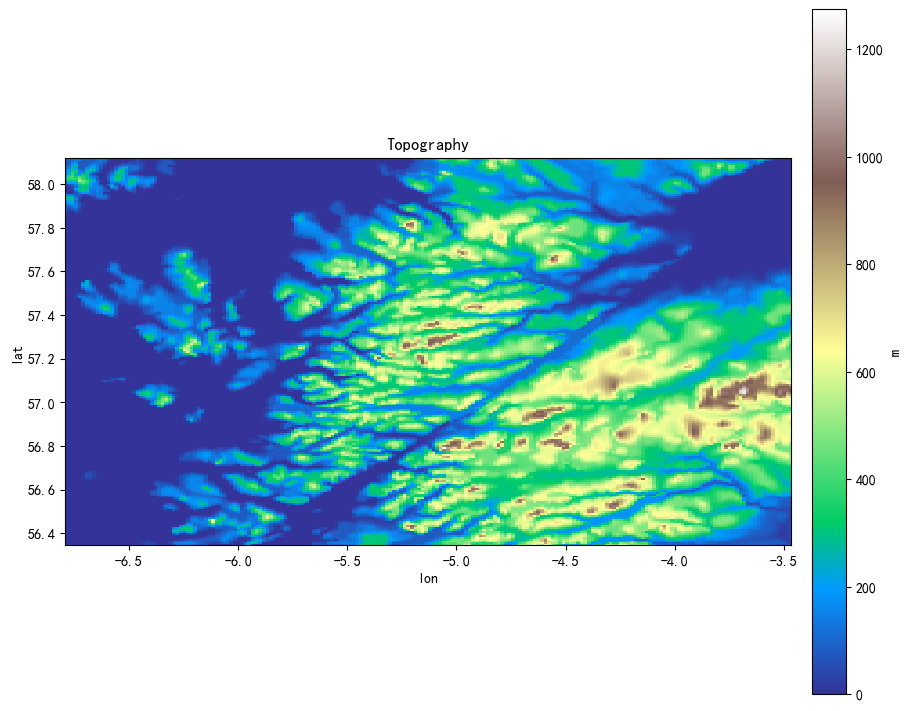

In [7]:
#地形数据
plot_topography = ensure_2d(topography_da)

topography_fig, topography_ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
topography_im = plot_field(
    topography_ax,
    plot_topography,
    "Topography",
    cmap="terrain",
)
topography_fig.colorbar(
    topography_im,
    ax=topography_ax,
    pad=0.02,
    label=plot_topography.attrs.get("units", ""),
)

plt.show()

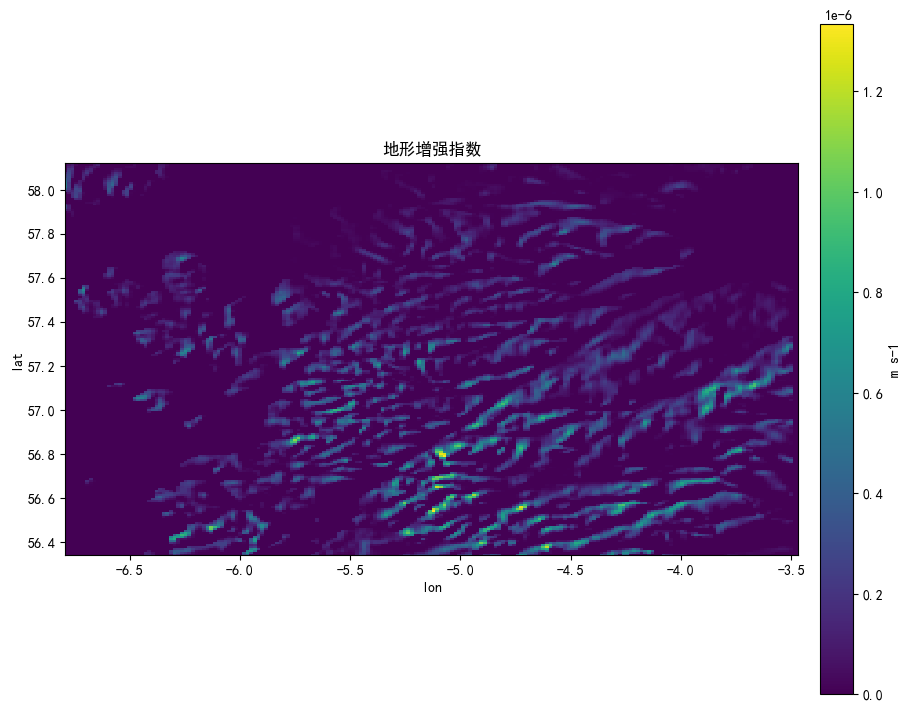

In [8]:
# 修改后算法结果——地形降水增量
plot_migrated = ensure_2d(migrated_da)

migrated_fig, migrated_ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
migrated_vmax = float(np.nanmax(plot_migrated.values))
if not np.isfinite(migrated_vmax) or migrated_vmax <= 0.0:
    migrated_vmax = 1.0e-12
migrated_norm = Normalize(vmin=0.0, vmax=migrated_vmax)
migrated_im = plot_field(
    migrated_ax,
    plot_migrated,
    "地形增强指数",
    cmap="viridis",
    norm=migrated_norm,
)
migrated_fig.colorbar(
    migrated_im,
    ax=migrated_ax,
    pad=0.02,
    label=plot_migrated.attrs.get("units", ""),
)

plt.show()

### 结果对比

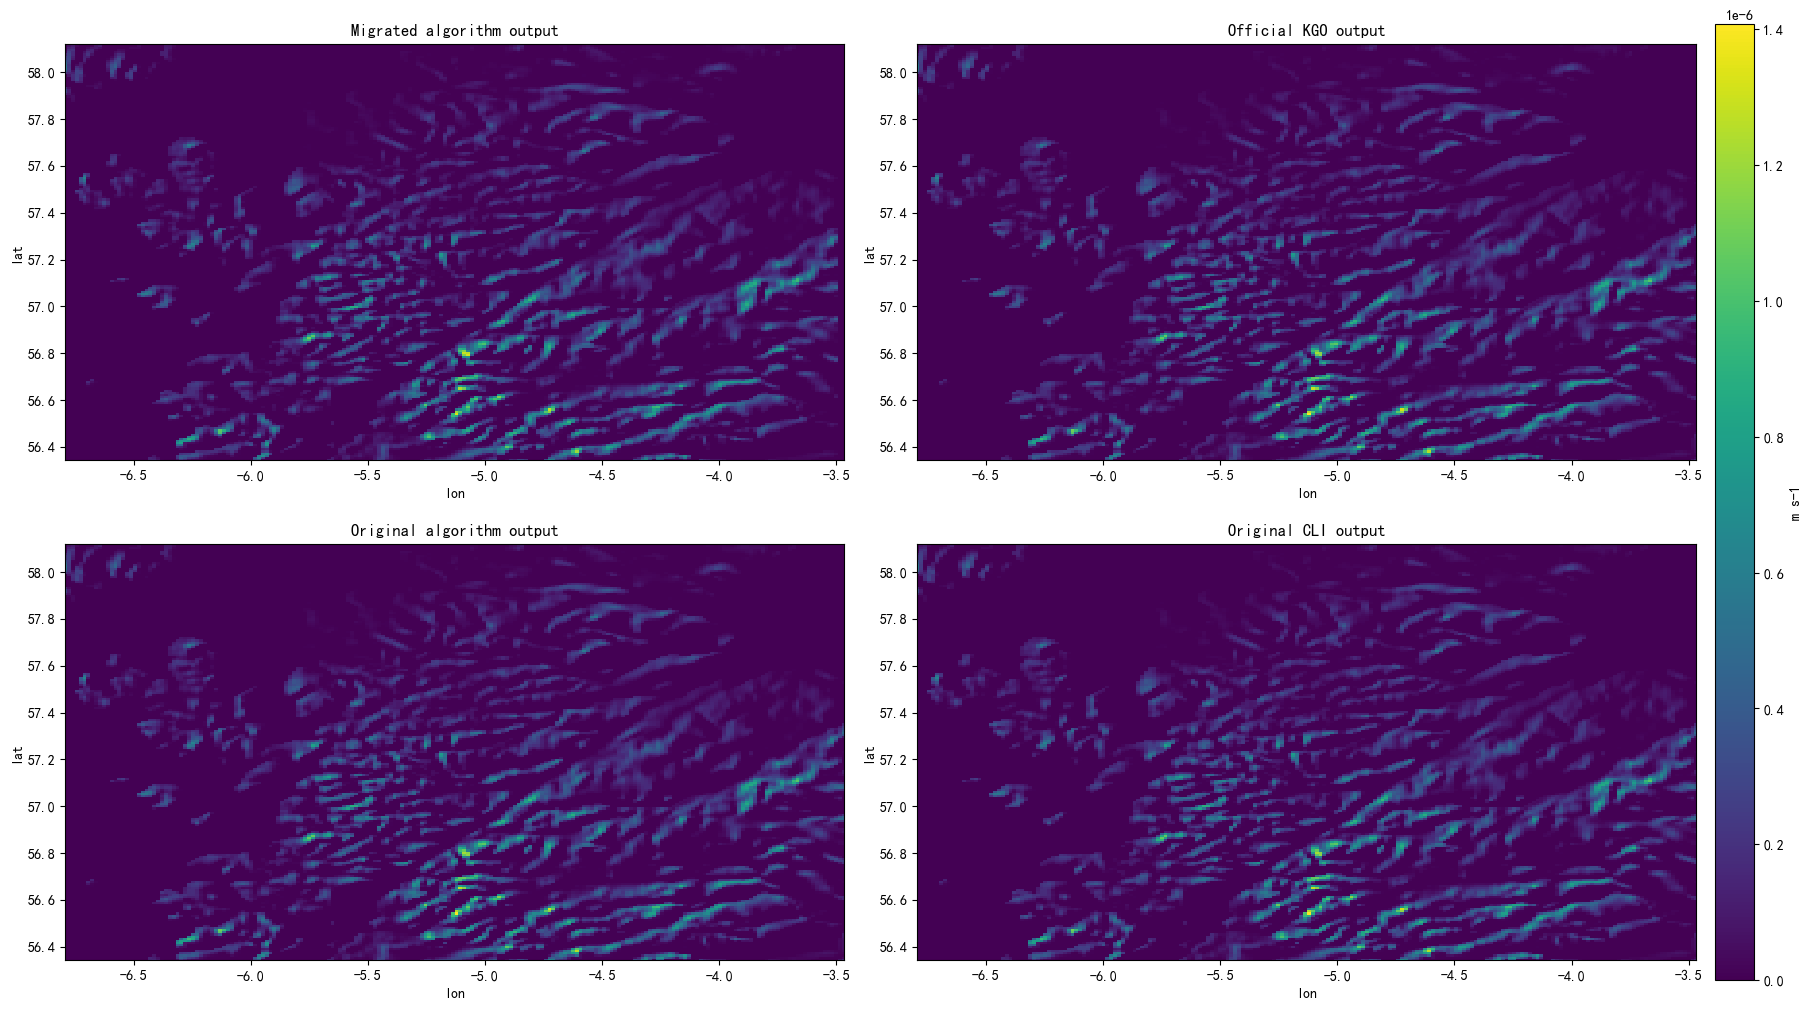

In [9]:
plot_kgo = ensure_2d(kgo_da)
plot_original = ensure_2d(original_da)
plot_cli = ensure_2d(cli_da)

result_stack = np.stack([
    plot_migrated.values,
    plot_kgo.values,
    plot_original.values,
    plot_cli.values,
])
result_norm = Normalize(
    vmin=float(np.nanmin(result_stack)),
    vmax=float(np.nanmax(result_stack)),
)

result_fig = plt.figure(figsize=(18, 10), constrained_layout=True)
result_gs = result_fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05])
result_axes = np.array(
    [
        [result_fig.add_subplot(result_gs[0, 0]), result_fig.add_subplot(result_gs[0, 1])],
        [result_fig.add_subplot(result_gs[1, 0]), result_fig.add_subplot(result_gs[1, 1])],
    ]
)
result_cax = result_fig.add_subplot(result_gs[:, 2])

result_im = plot_field(
    result_axes[0, 0],
    plot_migrated,
    "Migrated algorithm output",
    cmap="viridis",
    norm=result_norm,
)
plot_field(
    result_axes[0, 1],
    plot_kgo,
    "Official KGO output",
    cmap="viridis",
    norm=result_norm,
)
plot_field(
    result_axes[1, 0],
    plot_original,
    "Original algorithm output",
    cmap="viridis",
    norm=result_norm,
)
plot_field(
    result_axes[1, 1],
    plot_cli,
    "Original CLI output",
    cmap="viridis",
    norm=result_norm,
)

result_fig.colorbar(
    result_im,
    cax=result_cax,
    label=plot_migrated.attrs.get("units", ""),
)

plt.show()


In [10]:
comparison_stats = [
    diff_stats("Migrated vs KGO", migrated_da, kgo_da),
    diff_stats("Migrated vs Original", migrated_da, original_da),
    diff_stats("Migrated vs Original CLI", migrated_da, cli_da),
    diff_stats("Original vs Original CLI", original_da, cli_da),
    diff_stats("Original CLI vs KGO", cli_da, kgo_da),
]

comparison_stats


[{'comparison': 'Migrated vs KGO',
  'max_abs_error': 4.716171133622993e-07,
  'mean_abs_error': 3.329471587321109e-09,
  'rmse': 1.1895297191699683e-08,
  'match_default_tol': False,
  'match_atol_1e6': True,
  'units': 'm s-1'},
 {'comparison': 'Migrated vs Original',
  'max_abs_error': 4.716171133622993e-07,
  'mean_abs_error': 3.329471587321109e-09,
  'rmse': 1.1895297191699683e-08,
  'match_default_tol': False,
  'match_atol_1e6': True,
  'units': 'm s-1'},
 {'comparison': 'Migrated vs Original CLI',
  'max_abs_error': 4.716171133622993e-07,
  'mean_abs_error': 3.329471587321109e-09,
  'rmse': 1.1895297191699683e-08,
  'match_default_tol': False,
  'match_atol_1e6': True,
  'units': 'm s-1'},
 {'comparison': 'Original vs Original CLI',
  'max_abs_error': 0.0,
  'mean_abs_error': 0.0,
  'rmse': 0.0,
  'match_default_tol': True,
  'match_atol_1e6': True,
  'units': 'm s-1'},
 {'comparison': 'Original CLI vs KGO',
  'max_abs_error': 1.7053025658242404e-13,
  'mean_abs_error': 1.28002

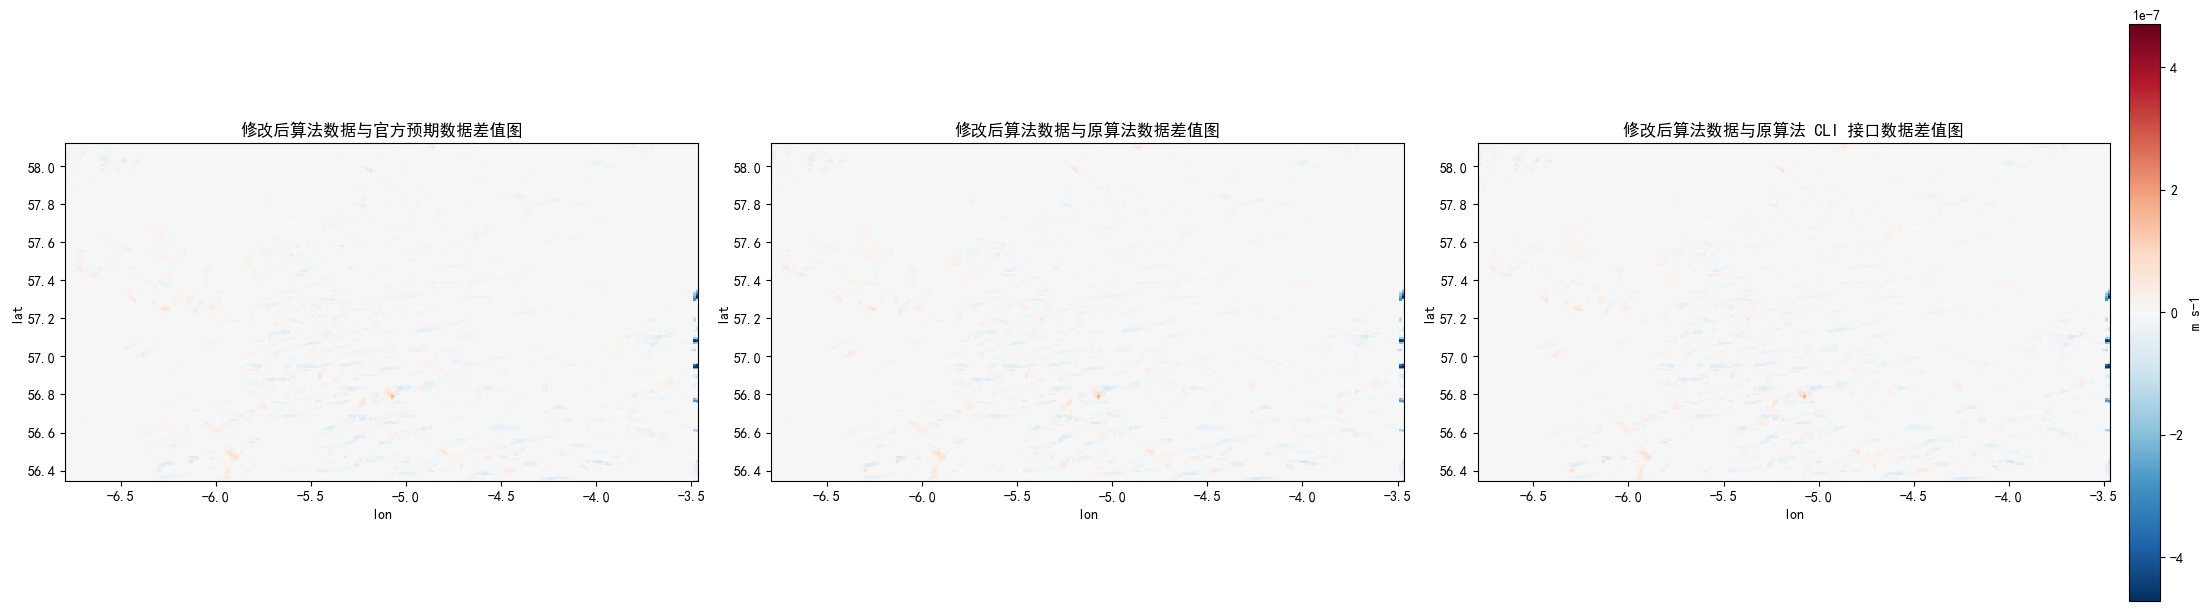

In [11]:
aligned_migrated_kgo, aligned_kgo = align_2d_with_axis_flip(plot_migrated, plot_kgo)
aligned_migrated_original, aligned_original = align_2d_with_axis_flip(plot_migrated, plot_original)
aligned_migrated_cli, aligned_cli = align_2d_with_axis_flip(plot_migrated, plot_cli)

diff_migrated_kgo = aligned_migrated_kgo - aligned_kgo
diff_migrated_original = aligned_migrated_original - aligned_original
diff_migrated_cli = aligned_migrated_cli - aligned_cli
diff_units = plot_migrated.attrs.get("units", "")

diff_stack = np.stack([
    diff_migrated_kgo.values,
    diff_migrated_original.values,
    diff_migrated_cli.values,
])
diff_abs_max = float(np.nanmax(np.abs(diff_stack)))
if (not np.isfinite(diff_abs_max)) or diff_abs_max <= 0.0:
    data_scale = float(np.nanmax(np.abs(result_stack)))
    if not np.isfinite(data_scale) or data_scale <= 0.0:
        data_scale = 1.0e-12
    diff_abs_max = max(data_scale * 1.0e-3, 1.0e-12)

diff_norm = Normalize(vmin=-diff_abs_max, vmax=diff_abs_max)

diff_fig = plt.figure(figsize=(22, 6), constrained_layout=True)
diff_gs = diff_fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05])
diff_axes = [
    diff_fig.add_subplot(diff_gs[0, 0]),
    diff_fig.add_subplot(diff_gs[0, 1]),
    diff_fig.add_subplot(diff_gs[0, 2]),
]
diff_cax = diff_fig.add_subplot(diff_gs[0, 3])

diff_im = plot_field(
    diff_axes[0],
    diff_migrated_kgo,
    "修改后算法数据与官方预期数据差值图",
    cmap="RdBu_r",
    norm=diff_norm,
)
plot_field(
    diff_axes[1],
    diff_migrated_original,
    "修改后算法数据与原算法数据差值图",
    cmap="RdBu_r",
    norm=diff_norm,
)
plot_field(
    diff_axes[2],
    diff_migrated_cli,
    "修改后算法数据与原算法 CLI 接口数据差值图",
    cmap="RdBu_r",
    norm=diff_norm,
)

diff_fig.colorbar(diff_im, cax=diff_cax, label=diff_units)

plt.show()


## ApplyOrographicEnhancement 应用对比（原算法 vs 迁移算法）


In [12]:
# ApplyOrographicEnhancement 对比：原算法与迁移算法
from datetime import datetime

import xarray as xr
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize

# 说明：原算法插件使用 Iris（二维投影场流程）；迁移算法使用 xarray（六维网格流程）
try:
    import iris
    from cf_units import Unit
except Exception as exc:
    raise RuntimeError(f"当前环境缺少 iris/cf_units，无法运行原算法 ApplyOE 对比：{exc}")

from improver.nowcasting.utilities import ApplyOrographicEnhancement as OriginalApplyOrographicEnhancement


from orographic_enhancement.src.apply_orographic_enhancement import (
    ApplyOrographicEnhancement as MigratedApplyOrographicEnhancement,
)



def harmonize_time_calendar_to_standard(cube):
    """将 time 坐标统一到 standard calendar，避免原算法时间匹配报错。"""
    out = cube.copy()
    if out.coords('time'):
        t = out.coord('time').copy()
        time_dims = out.coord_dims('time')
        # 转为秒并固定 standard calendar
        t.convert_units('seconds since 1970-01-01 00:00:00')
        t.units = Unit('seconds since 1970-01-01 00:00:00', calendar='standard')
        out.remove_coord('time')
        if len(time_dims) == 1:
            try:
                out.add_dim_coord(t, time_dims[0])
            except Exception:
                out.add_aux_coord(t, data_dims=time_dims)
        else:
            out.add_aux_coord(t)
    return out


def squeeze_cube_to_projected_2d(cube):
    """保留投影二维主场（projection_y/x），其余维度取第 0 个索引。"""
    out = cube.copy()
    y_name = 'projection_y_coordinate'
    x_name = 'projection_x_coordinate'
    y_dim = out.coord_dims(y_name)[0]
    x_dim = out.coord_dims(x_name)[0]
    indexer = [0] * out.ndim
    indexer[y_dim] = slice(None)
    indexer[x_dim] = slice(None)
    out = out[tuple(indexer)]
    return out


def standardize_precip_cube_for_plugin(precip_cube, oe_cube):
    """标准化降水立方体以适配插件处理。"""
    cube = precip_cube.copy()
    cube.rename('lwe_precipitation_rate')
    cube.units = 'mm hr-1'

    # 处理时间坐标：优先从地形增强立方体中获取时间信息
    if oe_cube.coords('time'):
        t = oe_cube.coord('time').copy()
        if t.ndim > 0:
            t = t[0]
        if cube.coords('time'):
            cube.remove_coord('time')
        cube.add_aux_coord(t)
    elif not cube.coords('time'):
        # 如果两个立方体都没有时间坐标，创建默认时间坐标
        t = iris.coords.AuxCoord(
            np.array([0.0], dtype=np.float64),
            standard_name='time',
            units=Unit('seconds since 1970-01-01 00:00:00', calendar='standard'),
        )
        cube.add_aux_coord(t)
    return cube


def to_meb6d_for_apply(data_2d: xr.DataArray, name: str) -> xr.DataArray:
    """将二维投影场包装为迁移算法要求的六维网格格式。

    注意：这里仅用于 ApplyOE 验证，不改坐标数值。
    将 projection_y/x 映射为 lat/lon 维名，以满足迁移算法的维度检查。
    """
    d2 = to_plot_2d(data_2d).copy()
    y_name, x_name = d2.dims

    da = d2.rename({y_name: 'lat', x_name: 'lon'})
    da = da.expand_dims(member=[0], level=[0], time=[np.datetime64('2023-09-20T06:00:00')], dtime=[0])
    da = da.transpose('member', 'level', 'time', 'dtime', 'lat', 'lon')
    da = da.astype(np.float32)
    da.name = name

    attrs = dict(da.attrs)
    attrs.setdefault('units', d2.attrs.get('units', 'mm hr-1'))
    attrs.setdefault('model', None)
    attrs.setdefault('dtime_units', 'hour')
    attrs.setdefault('level_type', 'isobaric')
    attrs.setdefault('time_type', 'UT')
    attrs.setdefault('time_bounds', [0, 0])
    da.attrs = attrs
    return da


def align_oe_to_precip_for_apply(
    oe_field: xr.DataArray,
    precip_field: xr.DataArray,
    *,
    mapping_source: xr.DataArray | None = None,
) -> xr.DataArray:
    """将 OE 场重采样到降水场网格，供 ApplyOE 使用。"""
    try:
        from orographic_enhancement.src.orographic_enhancement import (
            _get_grid_mapping_attrs,
            _needs_regridding,
            _regrid_scalar_field,
        )
    except ModuleNotFoundError:
        from src.orographic_enhancement import (
            _get_grid_mapping_attrs,
            _needs_regridding,
            _regrid_scalar_field,
        )

    def _spatial_2d(da: xr.DataArray) -> xr.DataArray:
        indexers = {dim: 0 for dim in da.dims if dim not in ("lat", "lon")}
        return da.isel(indexers, drop=True)

    oe_2d = _spatial_2d(oe_field)
    precip_2d = _spatial_2d(precip_field)

    if mapping_source is not None:
        mapping_attrs = _get_grid_mapping_attrs(mapping_source)
        if mapping_attrs:
            precip_2d = precip_2d.copy()
            precip_2d.attrs["grid_mapping_attrs"] = mapping_attrs

    if _needs_regridding(oe_2d, precip_2d):
        oe_2d = _regrid_scalar_field(oe_2d, precip_2d)

    aligned = xr.DataArray(
        np.broadcast_to(oe_2d.values.astype(np.float32), precip_field.shape),
        coords=precip_field.coords,
        dims=precip_field.dims,
        attrs=dict(oe_field.attrs),
        name=oe_field.name or "orographic_enhancement",
    )
    return aligned


def align_plot_to_reference(field: xr.DataArray, reference: xr.DataArray) -> xr.DataArray:
    """将绘图场对齐到参考降水网格，避免坐标系不一致导致 shape 不匹配。"""
    try:
        from orographic_enhancement.src.orographic_enhancement import (
            _get_grid_mapping_attrs,
            _needs_regridding,
            _regrid_scalar_field,
        )
    except ModuleNotFoundError:
        from src.orographic_enhancement import (
            _get_grid_mapping_attrs,
            _needs_regridding,
            _regrid_scalar_field,
        )

    field2d = orient_for_plot(to_plot_2d(field))
    ref2d = orient_for_plot(to_plot_2d(reference))
    y_name, x_name = ref2d.dims

    ref_for_grid = ref2d.copy()
    mapping_attrs = _get_grid_mapping_attrs(topography_da)
    if mapping_attrs and "grid_mapping_attrs" not in ref_for_grid.attrs:
        ref_for_grid.attrs["grid_mapping_attrs"] = mapping_attrs

    if _needs_regridding(field2d, ref_for_grid):
        field2d = _regrid_scalar_field(field2d, ref_for_grid)

    return field2d.assign_coords(
        {y_name: ref2d.coords[y_name], x_name: ref2d.coords[x_name]}
    )

In [13]:
# 使用原始文件做 ApplyOE 验证（与原算法流程一致）
rainrate_path = DATA_DIR / 'pre.nc'
oe_reference_path = DATA_DIR / 'original_cli_result.nc'

precip_cube = squeeze_cube_to_projected_2d(harmonize_time_calendar_to_standard(iris.load_cube(rainrate_path)))
oe_cube = squeeze_cube_to_projected_2d(harmonize_time_calendar_to_standard(iris.load_cube(oe_reference_path)))
plugin_precip_cube = standardize_precip_cube_for_plugin(precip_cube, oe_cube)

# 原算法 ApplyOE
original_apply_plugin = OriginalApplyOrographicEnhancement('add')
original_applied_cube = original_apply_plugin.process(iris.cube.CubeList([plugin_precip_cube]), oe_cube)[0]

rainrate_da = xr.DataArray.from_iris(plugin_precip_cube)
oe_da = xr.DataArray.from_iris(oe_cube)
original_applied_da = xr.DataArray.from_iris(original_applied_cube)

plot_rainrate_da = to_plot_2d(rainrate_da).copy()
plot_oe_da = to_plot_2d(oe_da).copy()
plot_original_applied_da = to_plot_2d(original_applied_da).copy()

### 算法调用

In [14]:
#调用ApplyOrographicEnhancement插件
migrated_apply_plugin = MigratedApplyOrographicEnhancement('add')
precip_meb6d = to_meb6d_for_apply(plot_rainrate_da, 'lwe_precipitation_rate')
oe_meb6d = to_meb6d_for_apply(plot_oe_da, 'orographic_enhancement')
oe_meb6d.attrs['units'] = plot_oe_da.attrs.get('units', precip_meb6d.attrs.get('units', 'mm hr-1'))

migrated_applied_meb = migrated_apply_plugin.process(precip_meb6d, oe_meb6d)

绘图

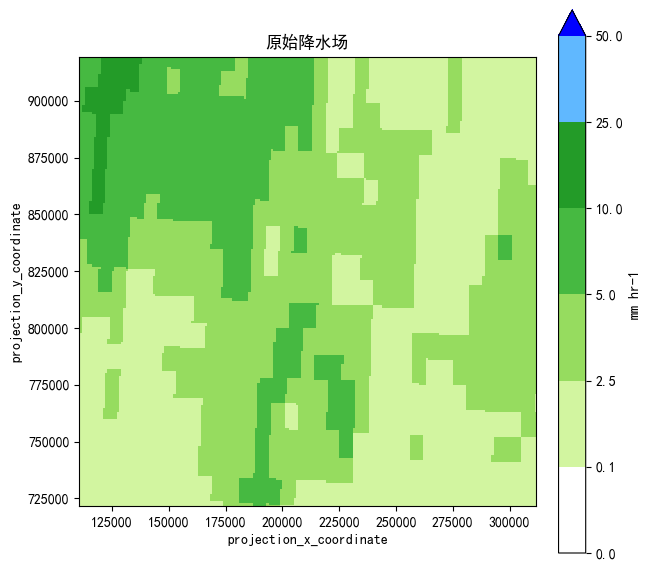

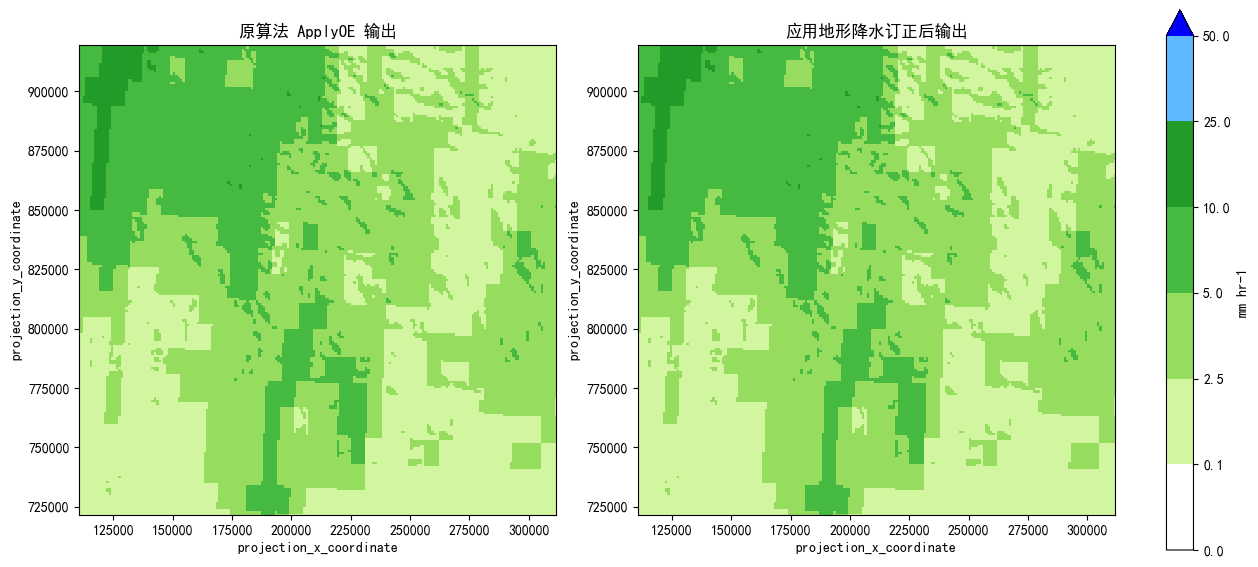

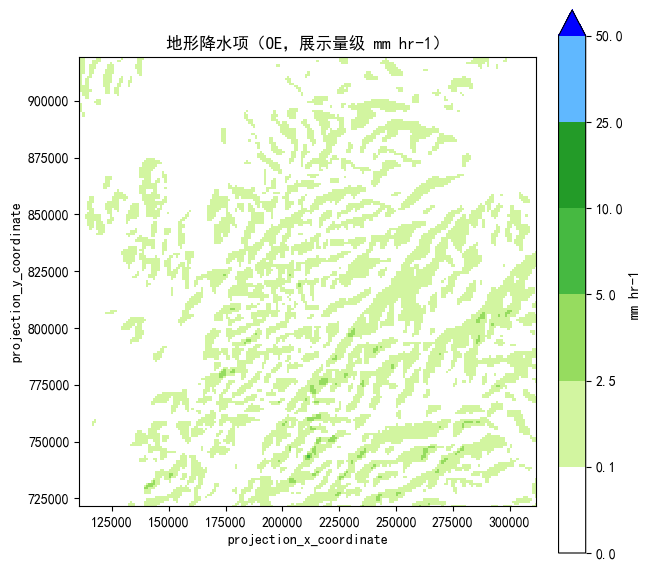

ApplyOE 对比 - 平均绝对误差: 8.698836e-08
ApplyOE 对比 - 最大绝对误差: 7.577240e-07
OE 统计 min=0.000000e+00, max=1.408448e-06, mean=5.695979e-08, p95=3.147094e-07
OE(展示量级 mm hr-1) 统计 min=0.000000e+00, max=5.070411e+00, mean=2.050552e-01, p95=1.132954e+00


In [15]:
plot_reference_da = orient_for_plot(plot_rainrate_da)

plot_migrated_applied_da = align_plot_to_reference(
    migrated_applied_meb.rename({'lat': 'projection_y_coordinate', 'lon': 'projection_x_coordinate'}),
    plot_reference_da,
)
plot_original_applied_da = align_plot_to_reference(plot_original_applied_da, plot_reference_da)
plot_rainrate_da = plot_reference_da.copy()

# 计算差值（迁移后 - 原算法）
apply_diff_da = (plot_migrated_applied_da - plot_original_applied_da).copy()

# 主结果图（三张图：原始降水、原算法输出、迁移算法输出）
main_stack = np.stack([
    plot_rainrate_da.values,
    plot_original_applied_da.values,
    plot_migrated_applied_da.values,
])

# 使用离散分级降水色标，深蓝色表示 >50
PRECIP_CLASS_BOUNDS = (
    0.0,
    0.1,
    2.5,
    5.0,
    10.0,
    25.0,
    50.0,
)
PRECIP_CLASS_RGB = (
    (255, 255, 255),  # [0, 0.1)
    (210, 245, 160),  # [0.1, 2.5)
    (150, 220, 95),   # [2.5, 5)
    (70, 185, 65),    # [5, 10)
    (35, 155, 40),    # [10, 25)
    (96, 184, 255),   # [25, 50)
)
precip_cmap = ListedColormap(np.array(PRECIP_CLASS_RGB, dtype=float) / 255.0)
precip_cmap.set_over((0.0, 0.0, 1.0))  # >50 使用深蓝色
main_norm = BoundaryNorm(PRECIP_CLASS_BOUNDS, precip_cmap.N, clip=False)

# 图1：原始降水场（单独出图，便于PPT插图）
raw_fig, raw_ax = plt.subplots(1, 1, figsize=(6.4, 5.8), constrained_layout=True)
im0 = plot_field(raw_ax, plot_rainrate_da, '原始降水场', cmap=precip_cmap, norm=main_norm)
raw_fig.colorbar(
    im0,
    ax=raw_ax,
    shrink=0.95,
    label=plot_rainrate_da.attrs.get('units', 'mm hr-1'),
    boundaries=PRECIP_CLASS_BOUNDS,
    ticks=PRECIP_CLASS_BOUNDS,
    extend='max',
)
plt.show()

# 图2：结果对比图（原算法 vs 迁移算法）
result_fig, result_axes = plt.subplots(1, 2, figsize=(12.5, 5.8), constrained_layout=True)
ax1, ax2 = result_axes[0], result_axes[1]
im1 = plot_field(ax1, plot_original_applied_da, '原算法 ApplyOE 输出', cmap=precip_cmap, norm=main_norm)
im2 = plot_field(ax2, plot_migrated_applied_da, '应用地形降水订正后输出', cmap=precip_cmap, norm=main_norm)
result_fig.colorbar(
    im2,
    ax=result_axes,
    shrink=0.95,
    label=plot_rainrate_da.attrs.get('units', 'mm hr-1'),
    boundaries=PRECIP_CLASS_BOUNDS,
    ticks=PRECIP_CLASS_BOUNDS,
    extend='max',
)
plt.show()

# 图3：地形降水项（OE）展示量级图（转换为 mm hr-1），复用相同业务色标和范围
oe_plot_display = plot_oe_da.copy()
oe_units = str(oe_plot_display.attrs.get('units', '')).strip().lower()
if oe_units in {'m s-1', 'm/s', 'm s^-1', 'm*s-1'}:
    oe_plot_display = oe_plot_display * (1000.0 * 3600.0)  # m/s -> mm/h
elif oe_units in {'mm s-1', 'mm/s', 'mm s^-1', 'mm*s-1'}:
    oe_plot_display = oe_plot_display * 3600.0  # mm/s -> mm/h
oe_plot_display.attrs['units'] = 'mm hr-1'

oe_fig, oe_ax = plt.subplots(1, 1, figsize=(6.4, 5.8), constrained_layout=True)
oe_im = plot_field(oe_ax, oe_plot_display, '地形降水项（OE，展示量级 mm hr-1）', cmap=precip_cmap, norm=main_norm)
oe_fig.colorbar(
    oe_im,
    ax=oe_ax,
    shrink=0.95,
    label='mm hr-1',
    boundaries=PRECIP_CLASS_BOUNDS,
    ticks=PRECIP_CLASS_BOUNDS,
    extend='max',
)
plt.show()

diff_abs = float(np.nanmax(np.abs(apply_diff_da.values)))
print(f"ApplyOE 对比 - 平均绝对误差: {float(np.nanmean(np.abs(apply_diff_da.values))):.6e}")
print(f"ApplyOE 对比 - 最大绝对误差: {diff_abs:.6e}")

# 诊断：输出地形降水项（OE）的量级，帮助解释“数值偏小”
oe_vals = np.asarray(plot_oe_da.values, dtype=float)
valid_oe = oe_vals[np.isfinite(oe_vals)]
if valid_oe.size > 0:
    print(
        "OE 统计 "
        f"min={float(np.nanmin(valid_oe)):.6e}, "
        f"max={float(np.nanmax(valid_oe)):.6e}, "
        f"mean={float(np.nanmean(valid_oe)):.6e}, "
        f"p95={float(np.nanpercentile(valid_oe, 95)):.6e}"
    )

oe_display_vals = np.asarray(oe_plot_display.values, dtype=float)
valid_oe_display = oe_display_vals[np.isfinite(oe_display_vals)]
if valid_oe_display.size > 0:
    print(
        "OE(展示量级 mm hr-1) 统计 "
        f"min={float(np.nanmin(valid_oe_display)):.6e}, "
        f"max={float(np.nanmax(valid_oe_display)):.6e}, "
        f"mean={float(np.nanmean(valid_oe_display)):.6e}, "
        f"p95={float(np.nanpercentile(valid_oe_display, 95)):.6e}"
    )

##  地形增强算法 CLI 应用

CLI 示例脚本：`orographic_enhancement/cli/dsc_orographic_enhancement.py`

```powershell
python -m orographic_enhancement.cli.dsc_orographic_enhancement
```

输出：`orographic_enhancement/test_data/orographic_enhancement_data/normalized_meb6d/cli_test_result.nc`

In [16]:
def load_cli_results():
    """加载CLI结果"""
    import xarray as xr
    from pathlib import Path
    
    base_dir = Path("../test_data/orographic_enhancement_data")
    normalized_dir = base_dir / "normalized_meb6d"
    modified_cli_path = normalized_dir / "cli_test_result.nc"
    original_cli_path = (normalized_dir / "original_cli_result.nc") if (normalized_dir / "original_cli_result.nc").exists() else (base_dir / "original_cli_result.nc")
    
    # 加载修改后算法CLI结果
    modified_cli_ds = xr.open_dataset(modified_cli_path, engine='netcdf4')
    if 'data' in modified_cli_ds:
        modified_cli_result = modified_cli_ds['data'].values
    else:
        for var_name in modified_cli_ds.data_vars:
            modified_cli_result = modified_cli_ds[var_name].values
            break
    
    # 加载原算法CLI结果
    original_cli_ds = xr.open_dataset(original_cli_path, engine='netcdf4')
    if 'data' in original_cli_ds:
        original_cli_result = original_cli_ds['data'].values
    else:
        for var_name in original_cli_ds.data_vars:
            original_cli_result = original_cli_ds[var_name].values
            break
    
    return modified_cli_result.squeeze(), original_cli_result.squeeze()

print("正在加载CLI结果...")
try:
    modified_cli_result, original_cli_result = load_cli_results()
    print(f"✅ CLI结果加载成功")
    print(f"   修改后CLI形状: {modified_cli_result.shape}")
    print(f"   原算法CLI形状: {original_cli_result.shape}")
except Exception as e:
    print(f"❌ CLI结果加载失败: {e}")
    modified_cli_result = None
    original_cli_result = None

正在加载CLI结果...
✅ CLI结果加载成功
   修改后CLI形状: (199, 202)
   原算法CLI形状: (199, 202)


正在生成插件算法与CLI结果对比图...


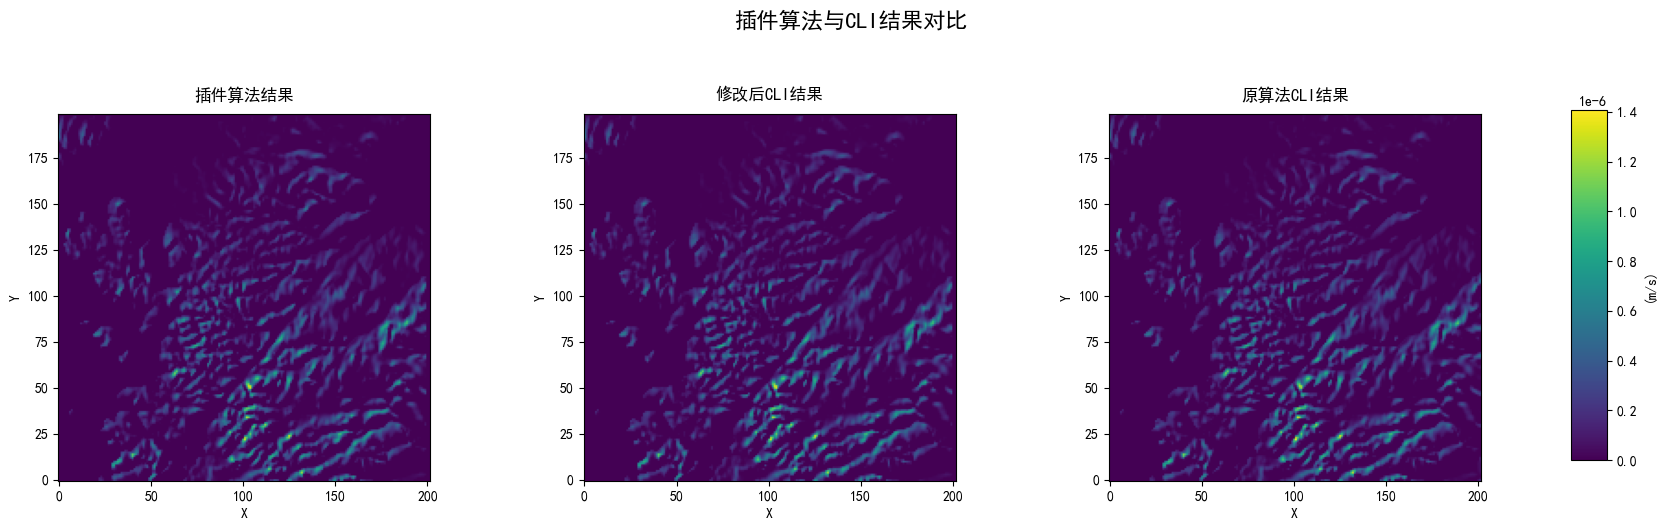


=== 插件算法与CLI结果统计对比 ===
算法类型                 平均值(m/s)        最大值(m/s)        最小值(m/s)       
-----------------------------------------------------------------
插件算法结果               0.00            0.00            0.00           
修改后CLI结果             0.00            0.00            0.00           
原算法CLI结果             0.00            0.00            0.00           

=== 差异分析 ===
插件算法 vs 修改后CLI - 平均绝对误差: 0.0000 m/s
修改后CLI vs 原算法CLI - 平均绝对误差: 0.0000 m/s


In [17]:
print("正在生成插件算法与CLI结果对比图...")

# 准备数据
modified_result_plot = plot_migrated
modified_cli_plot = modified_cli_result
original_cli_plot = plot_cli

# 计算三组数据的统一颜色范围
all_data = [modified_result_plot, modified_cli_plot, original_cli_plot]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

# ========== 创建1×3水平对比图 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'插件算法与CLI结果对比', fontsize=16, y=1.05)

# 1. 插件算法结果
im1 = axes[0].imshow(modified_result_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0].set_title(f'插件算法结果', fontsize=12, pad=10)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# 2. 修改后CLI结果
im2 = axes[1].imshow(modified_cli_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[1].set_title(f'修改后CLI结果', fontsize=12, pad=10)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

# 3. 原算法CLI结果
im3 = axes[2].imshow(original_cli_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[2].set_title(f'原算法CLI结果', fontsize=12, pad=10)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')

# 紧凑布局
plt.tight_layout()

# 添加垂直colorbar在右侧
plt.subplots_adjust(right=0.88)  # 为colorbar留出右侧空间
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im3, cax=cbar_ax, label='(m/s)')

plt.show()

# ========== 计算并显示统计信息 ==========
print(f"\n=== 插件算法与CLI结果统计对比 ===")
print(f"{'算法类型':<20} {'平均值(m/s)':<15} {'最大值(m/s)':<15} {'最小值(m/s)':<15}")
print("-" * 65)
print(f"{'插件算法结果':<20} {modified_result_plot.mean():<15.2f} {modified_result_plot.max():<15.2f} {modified_result_plot.min():<15.2f}")
print(f"{'修改后CLI结果':<20} {modified_cli_plot.mean():<15.2f} {modified_cli_plot.max():<15.2f} {modified_cli_plot.min():<15.2f}")
print(f"{'原算法CLI结果':<20} {original_cli_plot.mean():<15.2f} {original_cli_plot.max():<15.2f} {original_cli_plot.min():<15.2f}")

# 计算差异
print(f"\n=== 差异分析 ===")
diff_plugin_modified_cli = modified_result_plot - modified_cli_plot
diff_cli_between = modified_cli_plot - original_cli_plot

print(f"插件算法 vs 修改后CLI - 平均绝对误差: {np.abs(diff_plugin_modified_cli).mean():.4f} m/s")
print(f"修改后CLI vs 原算法CLI - 平均绝对误差: {np.abs(diff_cli_between).mean():.4f} m/s")